In [1]:
#Setup
#!conda remove pytorch torchvision torchaudio -y
#!conda install pytorch torchvision torchaudio -c pytorch -y
import torch
print(torch.__version__)

import torch._dynamo
print("All good!")

2.5.1
All good!


In [3]:
# Import and Data Loading
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Datasets
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
val_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# Loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1000, shuffle=False)

In [5]:
# Models
class ClsNet1(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 20)
        self.fc2 = nn.Linear(20, 50)
        self.fc3 = nn.Linear(50, 20)
        self.fc4 = nn.Linear(20, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        return self.fc4(x)  # logits


class ClsNet2(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 10)
        self.fc2 = nn.Linear(10, 20)
        self.fc3 = nn.Linear(20, 30)
        self.fc4 = nn.Linear(30, 20)
        self.fc5 = nn.Linear(20, 10)
        self.fc6 = nn.Linear(10, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.relu(self.fc4(x))
        x = self.relu(self.fc5(x))
        return self.fc6(x)


class ClsNet3(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 10)
        self.fc2 = nn.Linear(10, 40)
        self.fc3 = nn.Linear(40, 70)
        self.fc4 = nn.Linear(70, 40)
        self.fc5 = nn.Linear(40, 10)
        self.fc6 = nn.Linear(10, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.relu(self.fc4(x))
        x = self.relu(self.fc5(x))
        return self.fc6(x)

In [7]:
# Training Function
def train_cls(model, tr_loader, val_loader, epochs=20, lr=0.01):
    model = model.to(device)
    crit = nn.CrossEntropyLoss()
    opt = optim.Adam(model.parameters(), lr=lr)

    tr_losses, val_losses, val_accs = [], [], []

    for ep in range(epochs):
        model.train()
        run_loss = 0

        for data, target in tr_loader:
            data, target = data.to(device), target.to(device)

            opt.zero_grad()
            out = model(data)
            loss = crit(out, target)
            loss.backward()
            opt.step()

            run_loss += loss.item() * data.size(0)

        tr_loss = run_loss / len(tr_loader.dataset)
        tr_losses.append(tr_loss)

        model.eval()
        val_loss, corr, tot = 0, 0, 0

        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.to(device)
                out = model(data)

                loss = crit(out, target)
                val_loss += loss.item() * data.size(0)

                pred = out.argmax(dim=1)
                corr += (pred == target).sum().item()
                tot += target.size(0)

        val_loss /= len(val_loader.dataset)
        val_acc = corr / tot

        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"Epoch {ep+1}/{epochs} | Train Loss: {tr_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    return tr_losses, val_losses, val_accs

In [9]:
# Train Models
models = [ClsNet1(), ClsNet2(), ClsNet3()]

val_errs = []
train_tms = []
all_tr_losses = []
all_val_losses = []
all_val_accs = []

for i, mdl in enumerate(models, 1):
    print(f"\nTraining Net #{i}")
    start = time.time()

    tr_losses, val_losses, val_accs = train_cls(mdl, train_loader, val_loader)

    end = time.time()

    train_tms.append(end - start)
    val_errs.append(val_losses[-1])
    all_tr_losses.append(tr_losses)
    all_val_losses.append(val_losses)
    all_val_accs.append(val_accs)

best_idx = val_errs.index(min(val_errs))

print(f"\nBest Net: #{best_idx + 1}")


Training Net #1
Epoch 1/20 | Train Loss: 0.3484 | Val Loss: 0.3257 | Val Acc: 0.9042
Epoch 2/20 | Train Loss: 0.2427 | Val Loss: 0.2329 | Val Acc: 0.9386
Epoch 3/20 | Train Loss: 0.2207 | Val Loss: 0.2341 | Val Acc: 0.9396
Epoch 4/20 | Train Loss: 0.2210 | Val Loss: 0.2301 | Val Acc: 0.9344
Epoch 5/20 | Train Loss: 0.2134 | Val Loss: 0.2022 | Val Acc: 0.9422
Epoch 6/20 | Train Loss: 0.2077 | Val Loss: 0.2224 | Val Acc: 0.9435
Epoch 7/20 | Train Loss: 0.1972 | Val Loss: 0.2536 | Val Acc: 0.9376
Epoch 8/20 | Train Loss: 0.1951 | Val Loss: 0.2317 | Val Acc: 0.9418
Epoch 9/20 | Train Loss: 0.1937 | Val Loss: 0.2140 | Val Acc: 0.9476
Epoch 10/20 | Train Loss: 0.1905 | Val Loss: 0.2164 | Val Acc: 0.9470
Epoch 11/20 | Train Loss: 0.1916 | Val Loss: 0.2214 | Val Acc: 0.9440
Epoch 12/20 | Train Loss: 0.1835 | Val Loss: 0.2219 | Val Acc: 0.9448
Epoch 13/20 | Train Loss: 0.1830 | Val Loss: 0.2185 | Val Acc: 0.9454
Epoch 14/20 | Train Loss: 0.1804 | Val Loss: 0.2245 | Val Acc: 0.9457
Epoch 15/20 

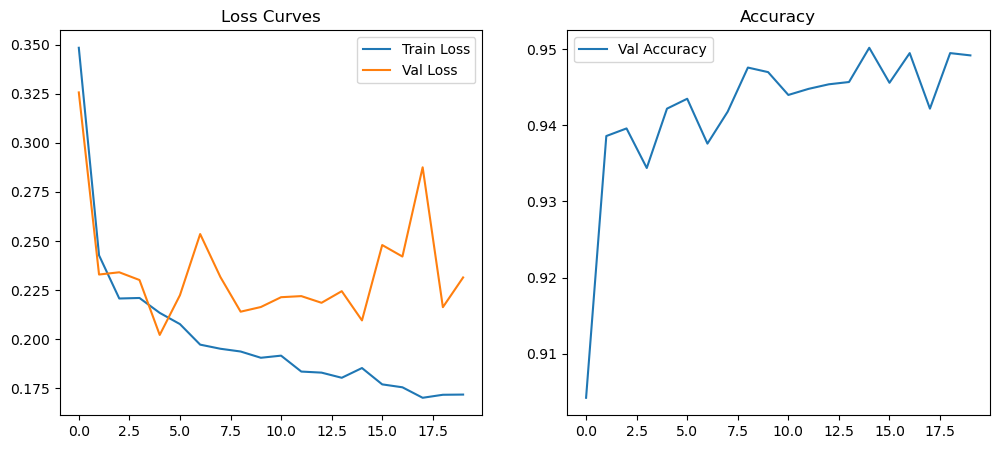

In [11]:
# Plots
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(all_tr_losses[best_idx], label='Train Loss')
plt.plot(all_val_losses[best_idx], label='Val Loss')
plt.legend()
plt.title("Loss Curves")

plt.subplot(1,2,2)
plt.plot(all_val_accs[best_idx], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")

plt.show()

In [15]:
# Conclusion and Answers
print("\nConclusion")

for i in range(3):
    print(f"Net {i+1}:")
    print(f"  Val Loss: {all_val_losses[i][-1]:.4f}")
    print(f"  Val Acc: {all_val_accs[i][-1]:.4f}")
    print(f"  Train Time: {train_tms[i]:.2f}s")


print("\nWhich of the three models had the least amount of error for validation?")
print(f"- The model with the least validation error is Network #{best_idx + 1}.")
print("- Training times for each model are printed above.")


Conclusion
Net 1:
  Val Loss: 0.2314
  Val Acc: 0.9492
  Train Time: 216.37s
Net 2:
  Val Loss: 0.4169
  Val Acc: 0.8815
  Train Time: 221.33s
Net 3:
  Val Loss: 0.3096
  Val Acc: 0.9263
  Train Time: 228.35s

Which of the three models had the least amount of error for validation?
- The model with the least validation error is Network #1.
- Training times for each model are printed above.
